Tugas Pertemuan 4 Implementasi Clustering untuk Menemukan Pola pada Data

**Nama:** Dewi Ainun Amaliah 

**NPM:** 50423366

**Dataset:** Customer Personality Analysis (Kaggle) https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?resource=download

mengimplementasikan algoritma K-Means Clustering dengan mengikuti metodologi **CRISP-DM**

## Tahap 1: Business Understanding

Menganalisis pola pada nota pengeluaran pelanggan memungkinkan sebuah bisnis untuk menargetkan promosi secara presisi, yang pada akhirnya menekan biaya marketing dan mengoptimalkan margin keuntungan. Pada tahap ini, kita mendefinisikan masalah dan tujuan metrik:

Latar Belakang: pemasaran yang disebar secara merata ke semua pelanggan seringkali membakar anggaran tanpa memberikan laba yang sepadan. Pelanggan memiliki preferensi dan daya beli yang berbeda.

Tujuan Proyek: Melakukan segmentasi pelanggan ke dalam kelompok yang homogen berdasarkan tingkat pendapatan dan kebiasaan belanja bulanan mereka pada kategori spesifik.

Kriteria Kesuksesan (Success Criteria): Menghasilkan minimal 3 klaster pelanggan yang terdefinisi dengan jelas dan terbukti secara kuantitatif (memiliki Silhouette Score di atas 0.4) sehingga tim bisnis dapat merancang 3 strategi promosi yang berbeda.

## Tahap 2: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [10]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [11]:
print("\nJumlah Data Kosong (Missing Values) per Kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Jumlah Data Kosong (Missing Values) per Kolom:
Income    24
dtype: int64


## Tahap 3: Data Preparation
Data mentah jarang bisa langsung diproses oleh algoritma K-Means. Kita perlu membersihkan data kosong, memilih fitur numerik inti pembentuk klaster, membuang data pencilan (outliers), dan menyamakan skala fitur menggunakan `StandardScaler`.

In [12]:
from sklearn.preprocessing import StandardScaler

df = df.dropna(subset=['Income']).reset_index(drop=True)

features = [
    'Income', 
    'MntWines', 
    'MntFruits', 
    'MntMeatProducts', 
    'MntFishProducts', 
    'MntSweetProducts'
]
df_cluster = df[features].copy()

df_cluster = df_cluster[df_cluster['Income'] < 200000]
df = df.loc[df_cluster.index].reset_index(drop=True)
df_cluster = df_cluster.reset_index(drop=True)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns)

print("Data setelah scaling:")
display(X_scaled.head())

Data setelah scaling:


,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts
0,0.286604,0.977779,1.548973,1.689714,2.453932,1.484340
1,-0.261407,-0.872375,-0.637338,-0.718196,-0.651178,-0.634081
2,0.912723,0.358096,0.568903,-0.178646,1.339745,-0.147087
3,-1.176680,-0.872375,-0.561948,-0.655768,-0.505056,-0.585381
4,0.293806,-0.392047,0.418123,-0.218777,0.152497,-0.000989


## Tahap 4: Modeling
Kita akan menggunakan algoritma K-Means. Untuk menentukan jumlah klaster terbaik (K), kita mengevaluasi metrik Inertia (Elbow Method) secara visual.

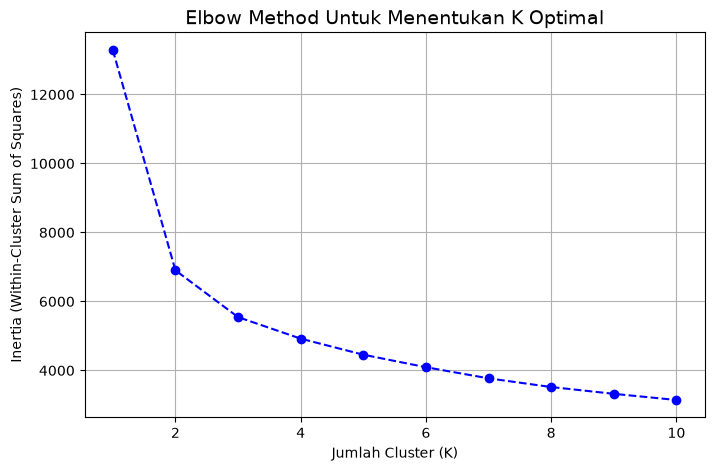

In [13]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method Untuk Menentukan K Optimal', fontsize=14)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [14]:
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

## Tahap 5: Evaluation & Visualisasi
Evaluasi berfungsi untuk menguji kualitas matematis dari klaster yang terbentuk dan menerjemahkannya ke dalam bahasa bisnis yang dapat dieksekusi. Di sini kita juga akan memvisualisasikan hasil pembagian klasternya.

In [15]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f'Silhouette Score: {sil_score:.3f}')

cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary['Total_Customers'] = df['Cluster'].value_counts()
print("\nRata-rata Pengeluaran per Cluster:")
display(cluster_summary)

Silhouette Score: 0.423

Rata-rata Pengeluaran per Cluster:


,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,Total_Customers
Cluster,,,,,,,
0,36437.24,73.83,5.72,31.45,8.84,5.67,1213
1,67211.19,604.95,25.57,216.83,36.83,28.04,561
2,75304.75,560.40,84.16,476.76,117.94,84.53,441


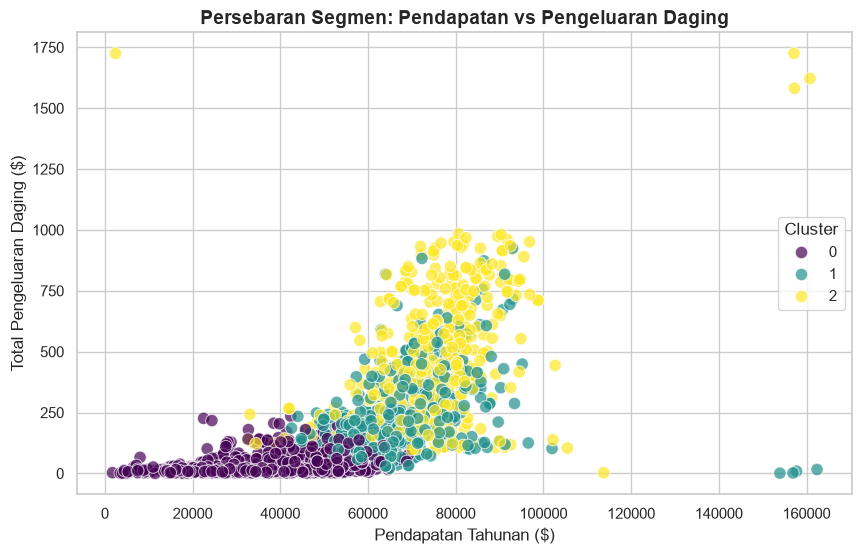

In [16]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Income', 
    y='MntMeatProducts', 
    hue='Cluster', 
    palette='viridis', 
    s=80, 
    alpha=0.7
)
plt.title('Persebaran Segmen: Pendapatan vs Pengeluaran Daging', fontsize=14, fontweight='bold')
plt.xlabel('Pendapatan Tahunan ($)', fontsize=12)
plt.ylabel('Total Pengeluaran Daging ($)', fontsize=12)
plt.legend(title='Cluster')
plt.show()

In [17]:
cluster_mean = df.groupby('Cluster')[features].mean().reset_index()
cluster_mean_melted = cluster_mean.melt(
    id_vars='Cluster', 
    var_name='Kategori_Produk', 
    value_name='Rata_Rata_Pengeluaran'
)

cluster_mean_melted = cluster_mean_melted[cluster_mean_melted['Kategori_Produk'] != 'Income']

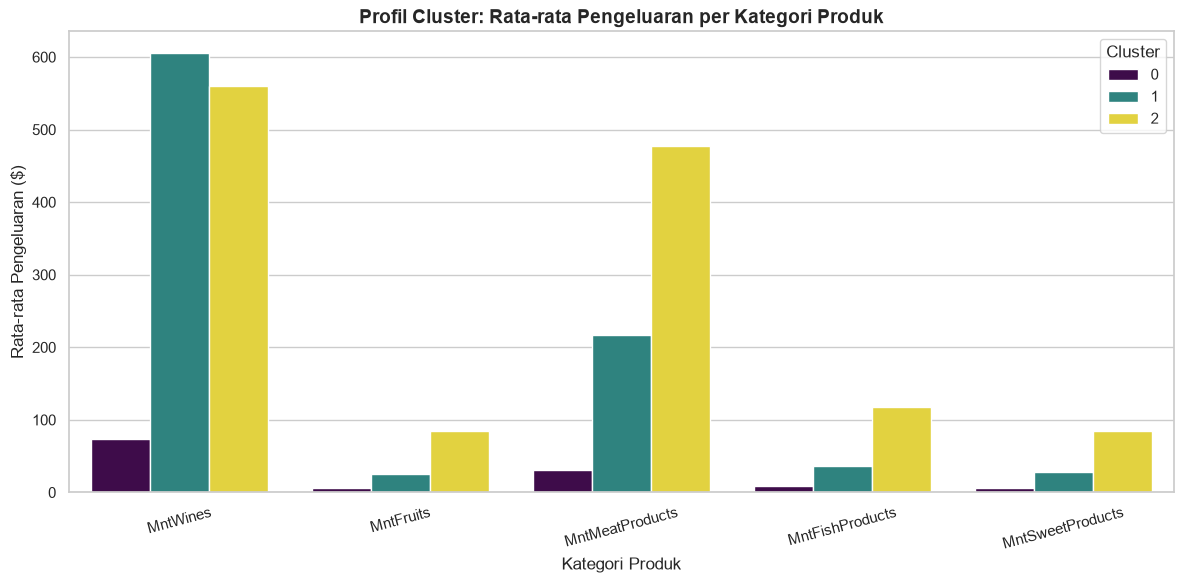

In [18]:

plt.figure(figsize=(12, 6))
sns.barplot(
    data=cluster_mean_melted, 
    x='Kategori_Produk', 
    y='Rata_Rata_Pengeluaran', 
    hue='Cluster', 
    palette='viridis'
)
plt.title('Profil Cluster: Rata-rata Pengeluaran per Kategori Produk', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Rata-rata Pengeluaran ($)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## Tahap 6: Deployment Preparation
Ekspor objek yang memiliki parameter state (Scaler dan K-Means) dari sesi training ini, agar pada tahap deployment, data input pengguna baru diproses dengan skala yang persis sama.

In [20]:
import joblib

joblib.dump(kmeans_final, 'kmeans_customer.pkl')
joblib.dump(scaler, 'scaler_customer.pkl')

print("Model dan Scaler berhasil disimpan! Siap untuk Deployment.")

Model dan Scaler berhasil disimpan! Siap untuk Deployment.
